# 09 — Holdout evaluation: post-training models (`best_extended` + `curriculum`)

**Summary:** One loop over registry rows with `tuning_stage` in `best_extended` or `curriculum`. Each row writes under `evaluations/holdout_best_extended/<model_id>/` or `evaluations/holdout_curriculum/<model_id>/` and updates `workflow_layout.json` with the matching `eval_kind`. **`MODEL_IDS`:** empty = all such rows; non-empty = filter to those ids **in list order**.

**Prerequisites:** Notebooks **03** (splits), **06** / **07** (trained models in the registry). Run after **08** if you are following the recommended pipeline.

**Disk cache:** Same contract as **08** — `eval_run_manifest.json` per model folder; set `FORCE_REGENERATE_HOLDOUT_PREDICTIONS` to bypass.

**Optional:** Set `SAVE_RENDER_PNGS = True` to write `{id}_target.png` and `{id}_pred.png` under each model's `out_dir/render_pngs/`. Exports use **`sample_df` only** (up to **`N_SAMPLES_PER_BUCKET` rows per `PERCENTILE_BUCKETS` entry** when `USE_PERCENTILE_BUCKETS` is true), **not** the full holdout. If bucket sampling fails, the fallback sample is at most 15 rows.

#### Colab / install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip -q install transformers peft accelerate bitsandbytes cairosvg pillow matplotlib lxml pandas tqdm

#### Parameters

In [13]:
import sys
from pathlib import Path

import pandas as pd
import torch

PROJECT_DIR = Path('/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

RUN_PROFILE_ID = 'run_1'
WORKFLOW_ROOT = PROJECT_DIR / 'outputs' / 'workflow_runs' / RUN_PROFILE_ID
MODELS_ROOT = WORKFLOW_ROOT / 'models'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'

MODEL_ID = 'Qwen/Qwen2.5-Coder-1.5B-Instruct'
MODEL_IDS = ['c1a57bce22fe4a00', '9c771d06b1014d22']  # empty: all registry rows with tuning_stage in best_extended or curriculum
MAX_NEW_TOKENS_BEST_EXTENDED_DEFAULT = 2048
MAX_NEW_TOKENS_CURRICULUM_DEFAULT = 4048
POSTPROCESS_METHOD = 'conservative_cleaner'

SEED = 42
USE_PERCENTILE_BUCKETS = True
PERCENTILE_BUCKETS = [
    ('0-10 percentile', 0.00, 0.10) #,
    #('40-60 percentile', 0.40, 0.60),
    #('80-100 percentile', 0.80, 1.00),
]
N_SAMPLES_PER_BUCKET = 10
N_TEXT_ROWS = 1
N_RENDER_ROWS = 1
PREVIEW_CHARS = 8000
FORCE_REGENERATE_HOLDOUT_PREDICTIONS = False

# If False: model runs on the full holdout (metrics CSV covers all rows). If True: GPU generation only on
# the stratified subset (N_SAMPLES_PER_BUCKET × len(PERCENTILE_BUCKETS) rows; partial CSV / not full holdout).
RUN_HOLDOUT_GENERATION_ON_BUCKET_SAMPLE_ONLY = True  # False = full holdout (for leaderboard / notebook 12)

# Export target + postprocessed prediction renders as PNG (under each model's out_dir/render_pngs/).
# Uses sample_df; when RUN_HOLDOUT_GENERATION_ON_BUCKET_SAMPLE_ONLY is True, sample_df is that same subset.
SAVE_RENDER_PNGS = True
RENDER_PNG_SIZE = 512
MAX_RENDER_PNG_ROWS = None  # None = every row of sample_df; int = cap below that

#### Run

In [4]:
import json

from src.core.dataframe import choose_first_existing
from src.core.modeling_splits import load_holdout_eval
from src.core.workflow_layout import update_workflow_layout_prediction
from src.eval.holdout_evaluation import (
    load_holdout_predictions_cached_or_run,
    merge_ranked_metadata,
    sample_percentile_buckets,
)
from src.eval.postprocess_presets import POSTPROCESS_METHODS
from src.training.lora.registry import load_registry, resolve_adapter_path

if POSTPROCESS_METHOD not in POSTPROCESS_METHODS:
    raise ValueError(f"Unknown POSTPROCESS_METHOD. Pick one of: {sorted(POSTPROCESS_METHODS)}")

holdout = load_holdout_eval(WORKFLOW_ROOT)
PROMPT_COL = choose_first_existing(holdout, ["prompt", "description", "text"], "holdout")
SVG_COL = choose_first_existing(holdout, ["svg", "svg_code", "target", "label"], "holdout")
reg = load_registry(PROJECT_DIR, models_root=MODELS_ROOT)
mask = reg["tuning_stage"].astype(str).isin(["best_extended", "curriculum"])
reg_sub = reg[mask].copy()
if len(MODEL_IDS):
    want = {str(x) for x in MODEL_IDS}
    reg_sub = reg_sub[reg_sub["model_id"].astype(str).isin(want)]
    order = {str(m): i for i, m in enumerate(MODEL_IDS)}
    reg_sub["_ord"] = reg_sub["model_id"].astype(str).map(lambda x: order.get(x, 9999))
    reg_sub = reg_sub.sort_values("_ord").drop(columns=["_ord"])
else:
    _stage_order = {"best_extended": 0, "curriculum": 1}
    reg_sub["_ord"] = reg_sub["tuning_stage"].astype(str).map(lambda x: _stage_order.get(x, 9))
    reg_sub = reg_sub.sort_values(["_ord", "model_id"]).drop(columns=["_ord"])

RANKED_PATH = PROCESSED_DIR / "train_ranked.csv"

holdout_merged = merge_ranked_metadata(holdout, RANKED_PATH)
if RUN_HOLDOUT_GENERATION_ON_BUCKET_SAMPLE_ONLY:
    if USE_PERCENTILE_BUCKETS:
        try:
            holdout_for_eval = sample_percentile_buckets(
                holdout_merged, PERCENTILE_BUCKETS, N_SAMPLES_PER_BUCKET, SEED
            )
        except Exception:
            _n = min(
                max(1, N_SAMPLES_PER_BUCKET * max(1, len(PERCENTILE_BUCKETS))),
                len(holdout_merged),
            )
            holdout_for_eval = holdout_merged.sample(n=_n, random_state=SEED).reset_index(drop=True)
    else:
        _n = min(
            max(1, N_SAMPLES_PER_BUCKET * max(1, len(PERCENTILE_BUCKETS))),
            len(holdout_merged),
        )
        holdout_for_eval = holdout_merged.sample(n=_n, random_state=SEED).reset_index(drop=True)
else:
    holdout_for_eval = holdout_merged

for _, rrow in reg_sub.iterrows():
    mid = str(rrow["model_id"])
    ts = str(rrow["tuning_stage"])
    adapter = resolve_adapter_path(PROJECT_DIR, str(rrow["adapter_dir"]))
    meta = json.loads(rrow["training_config_json"])
    if ts == "best_extended":
        eval_root = WORKFLOW_ROOT / "evaluations" / "holdout_best_extended"
        eval_kind = "holdout_best_extended"
        mxt = int(meta.get("max_new_tokens_default", MAX_NEW_TOKENS_BEST_EXTENDED_DEFAULT))
    else:
        eval_root = WORKFLOW_ROOT / "evaluations" / "holdout_curriculum"
        eval_kind = "holdout_curriculum"
        mxt = int(meta.get("max_new_tokens_default", MAX_NEW_TOKENS_CURRICULUM_DEFAULT))
    out_dir = eval_root / mid
    raw_df, cache_reason = load_holdout_predictions_cached_or_run(
        holdout_for_eval,
        PROMPT_COL,
        SVG_COL,
        adapter,
        MODEL_ID,
        WORKFLOW_ROOT,
        out_dir,
        POSTPROCESS_METHOD,
        max_new_tokens=mxt,
        force_regenerate=FORCE_REGENERATE_HOLDOUT_PREDICTIONS,
        id_col="id",
    )
    update_workflow_layout_prediction(
        PROJECT_DIR,
        WORKFLOW_ROOT,
        mid,
        out_dir / f"predictions_post_{POSTPROCESS_METHOD}.csv",
        eval_kind=eval_kind,
    )
    print(f"generated  model_id={mid}  ({ts})  {cache_reason}  rows={len(raw_df)}")

print("Generation cell finished.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Holdout SVG generation:   0%|          | 0/10 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


generated  model_id=c1a57bce22fe4a00  (curriculum)  regenerated  rows=10


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Holdout SVG generation:   0%|          | 0/10 [00:00<?, ?it/s]

generated  model_id=9c771d06b1014d22  (best_extended)  regenerated  rows=10
Generation cell finished.


,render_rate,xml_parse_rate
0,0.8,0.8


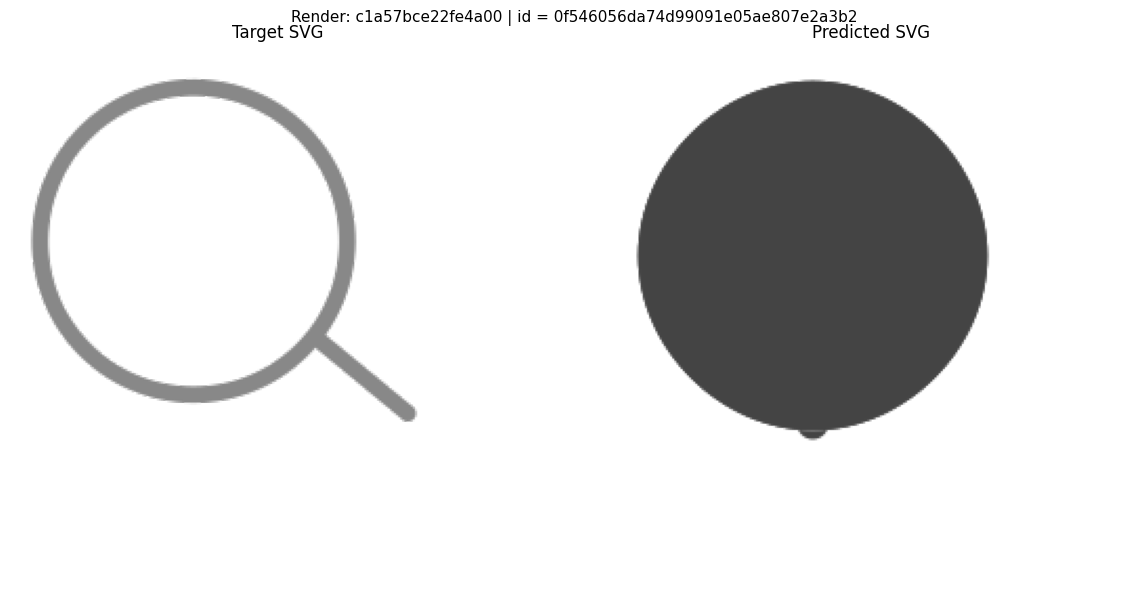

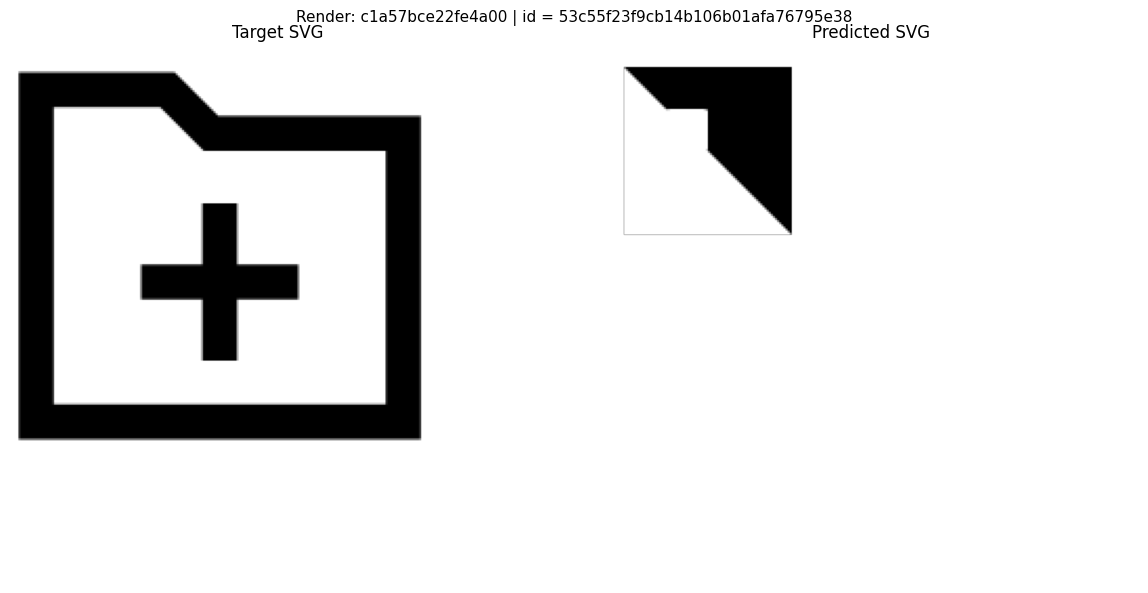

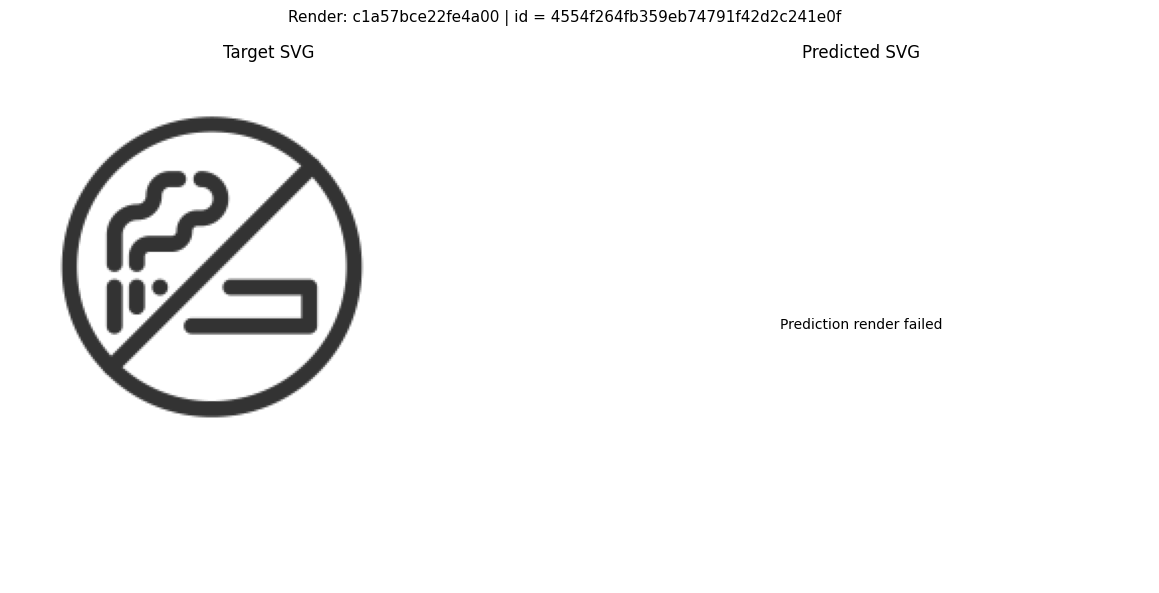

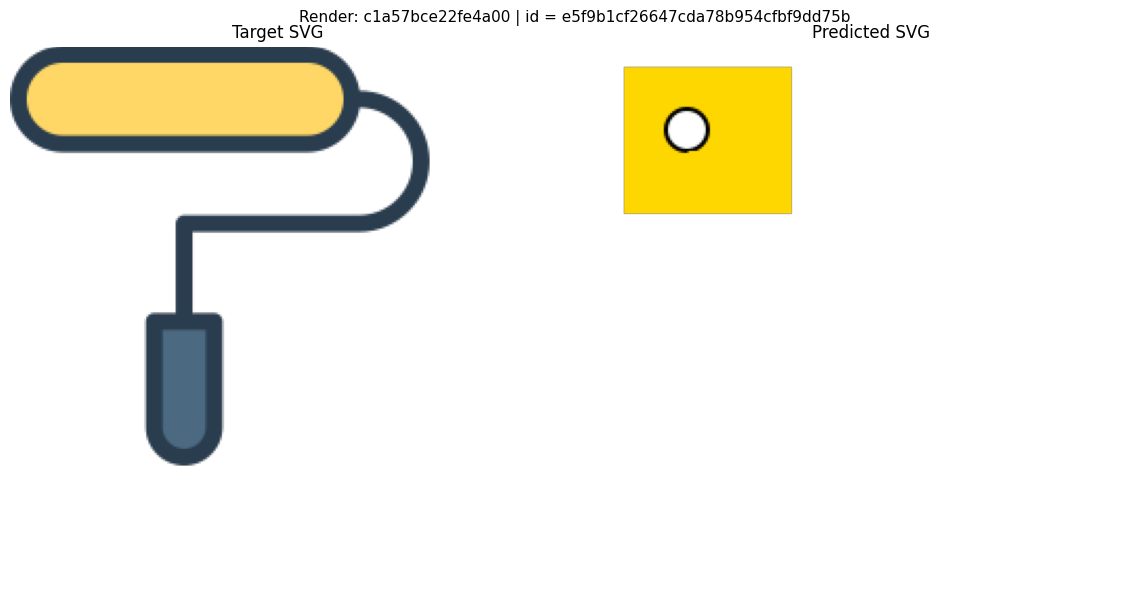

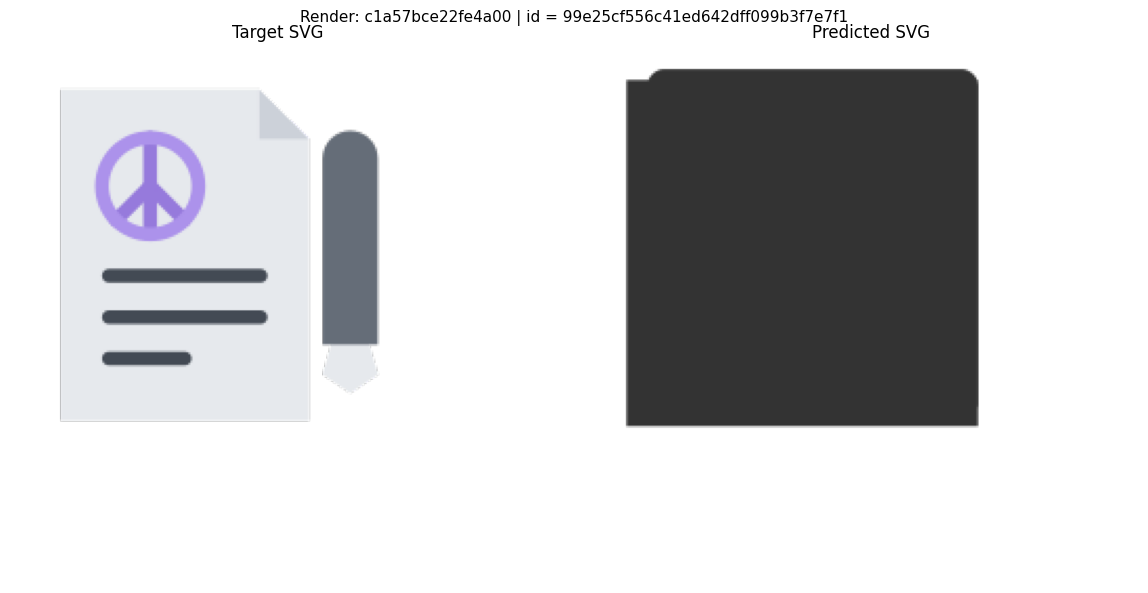

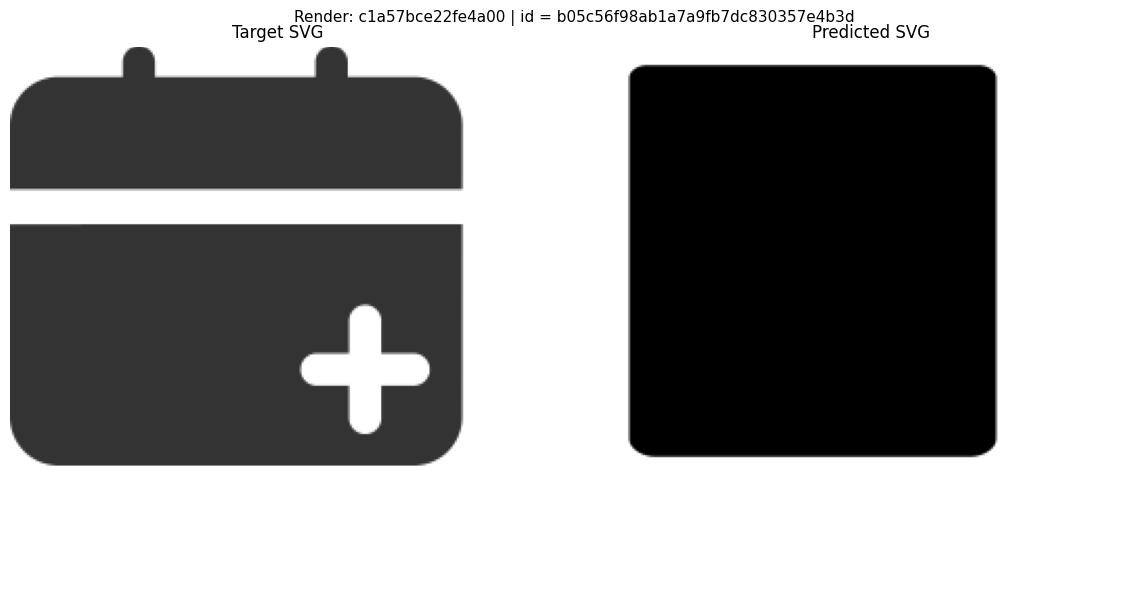

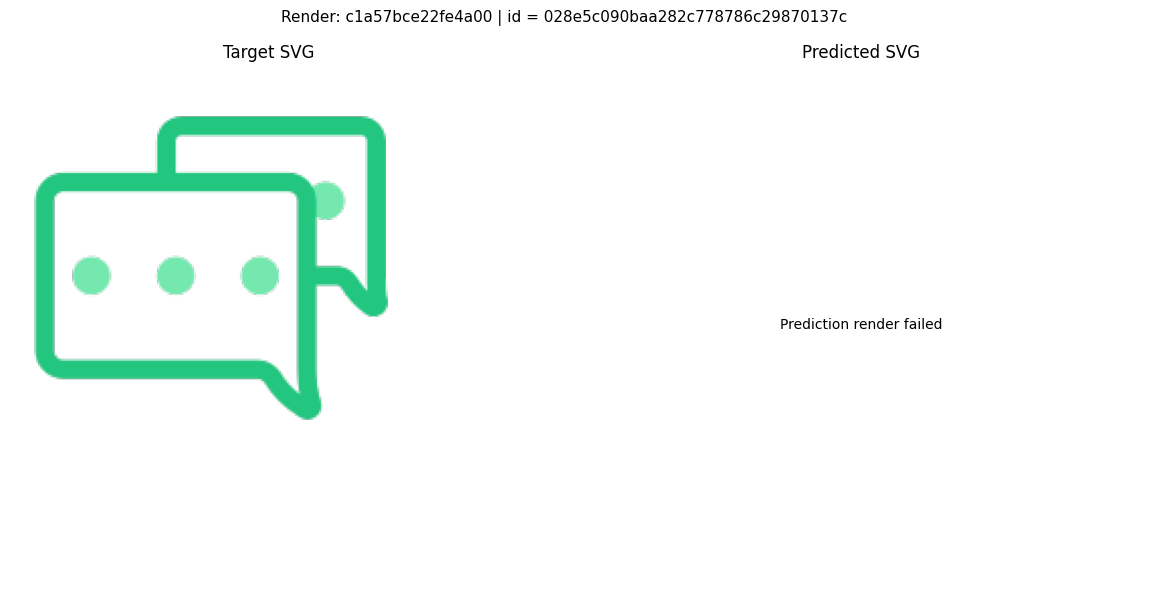

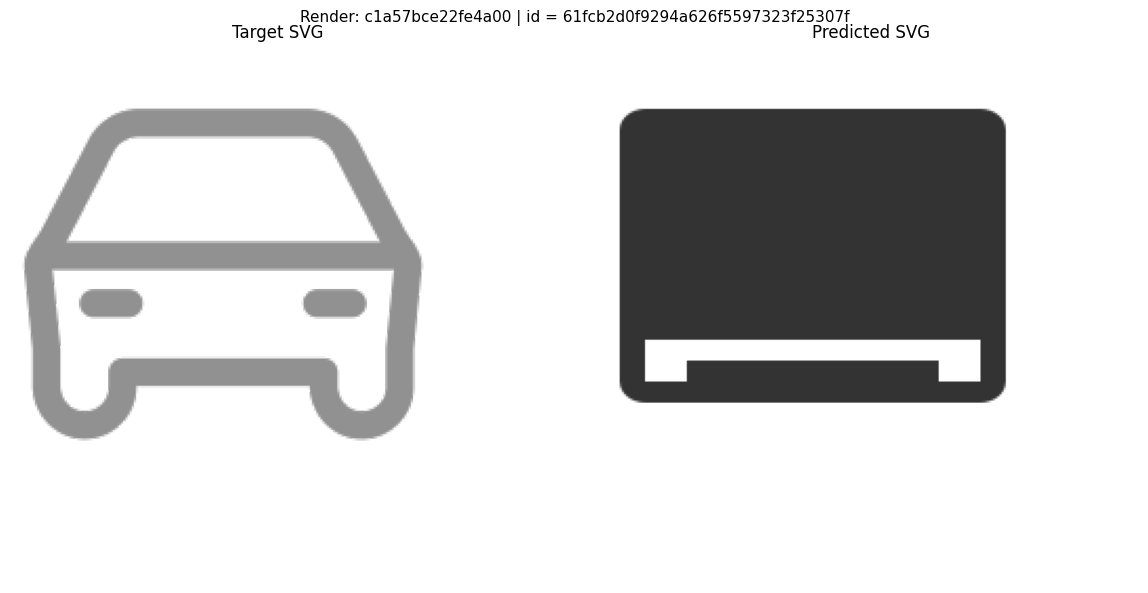

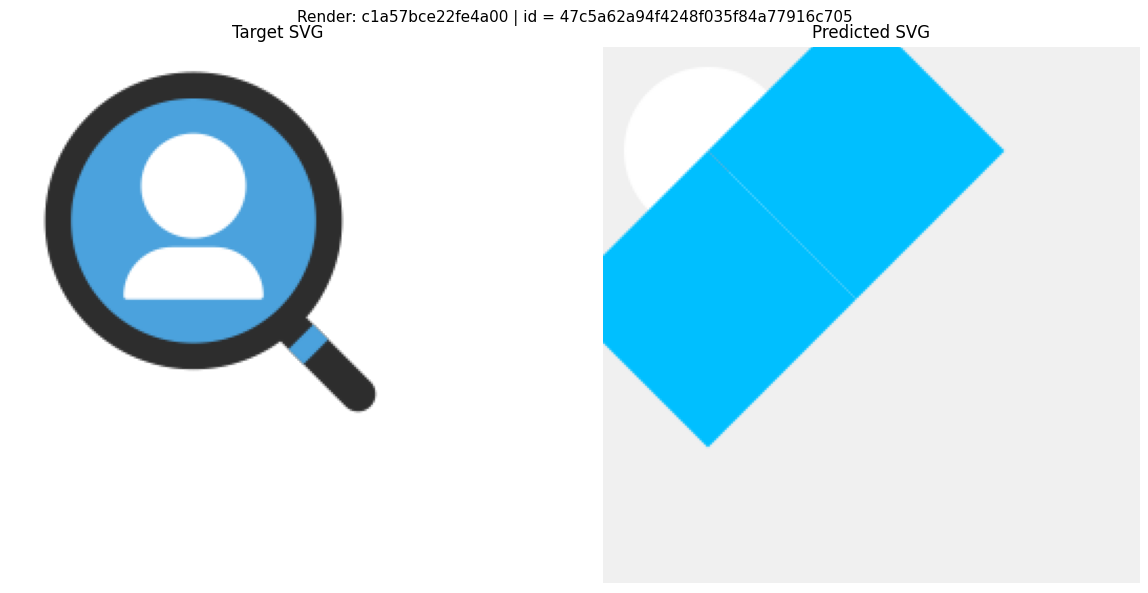

,render_rate,xml_parse_rate
0,0.6,0.6


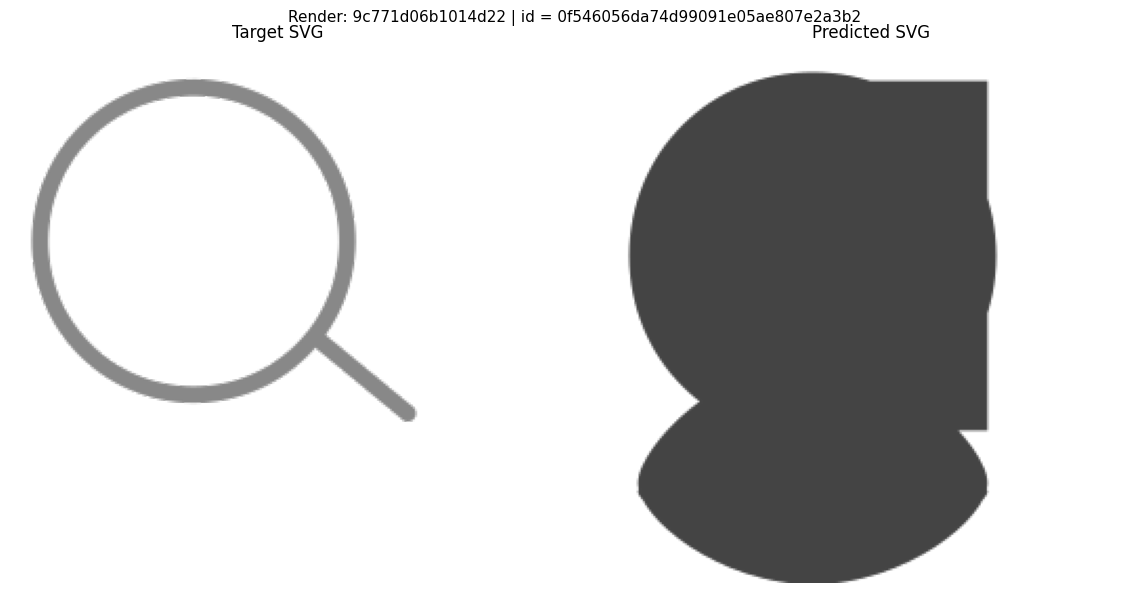

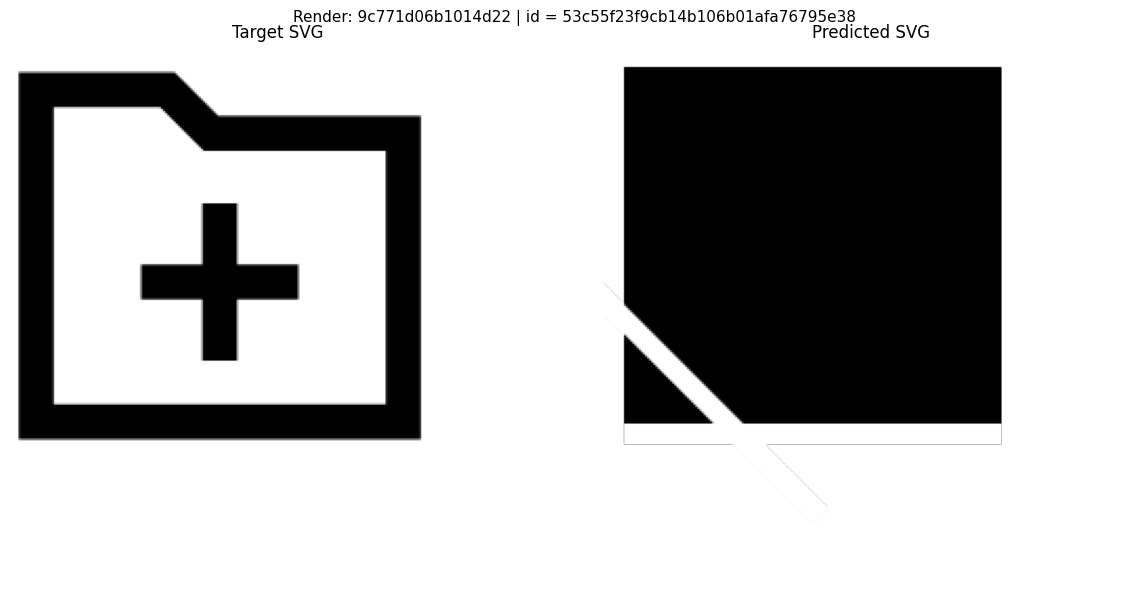

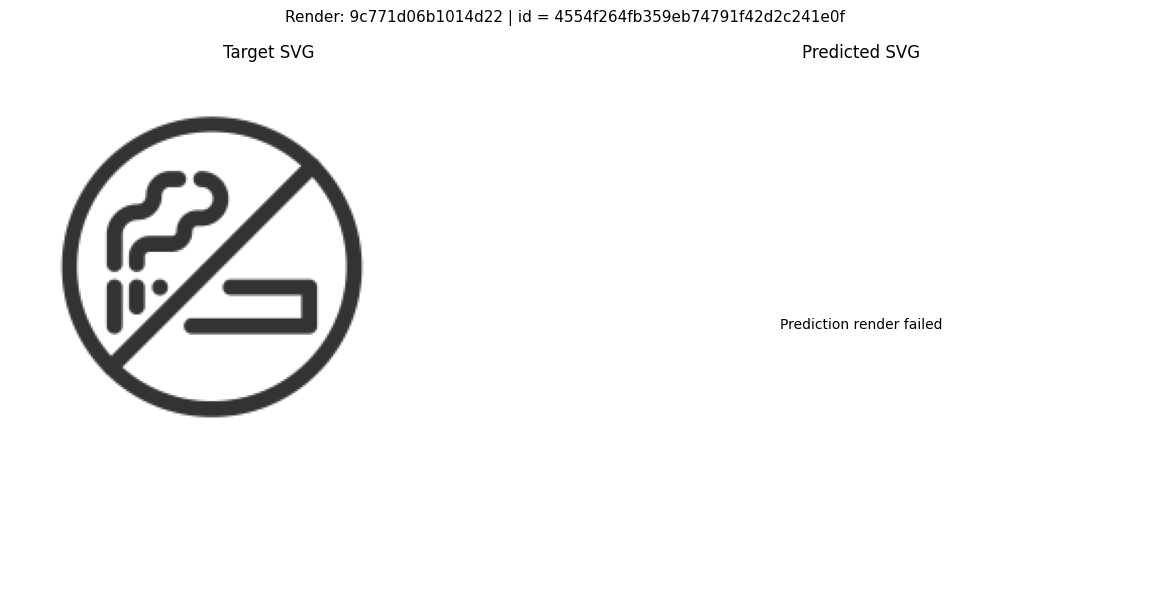

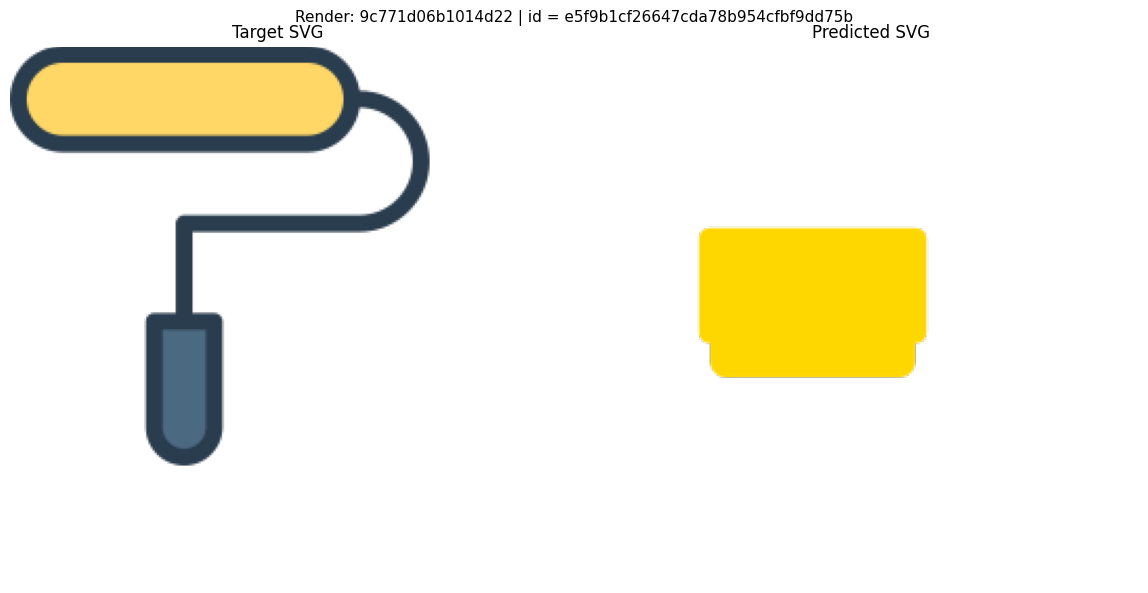

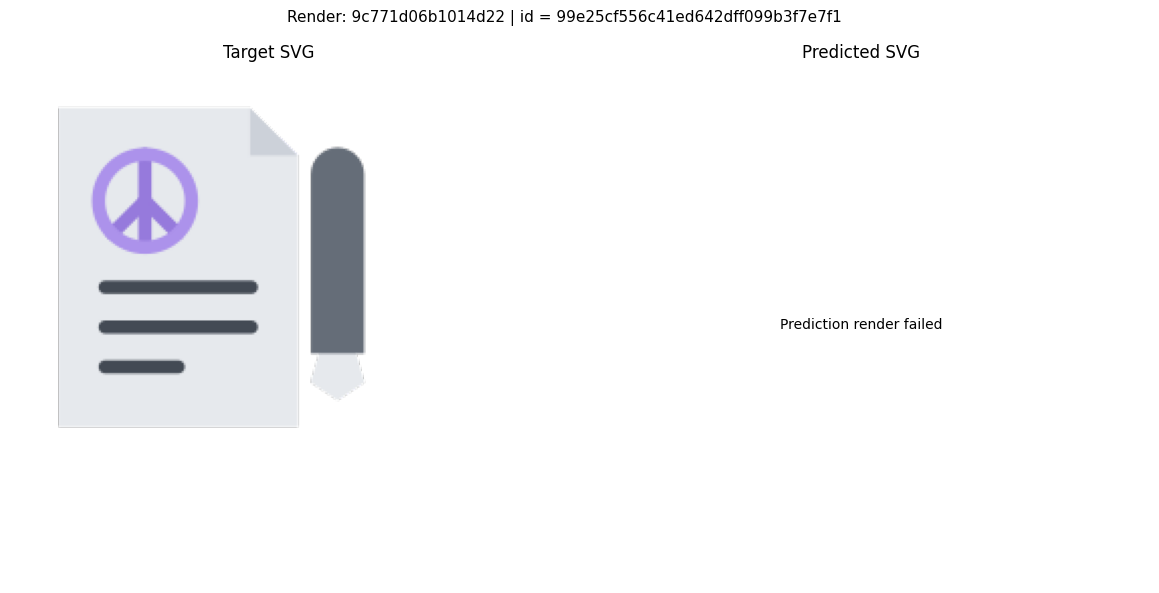

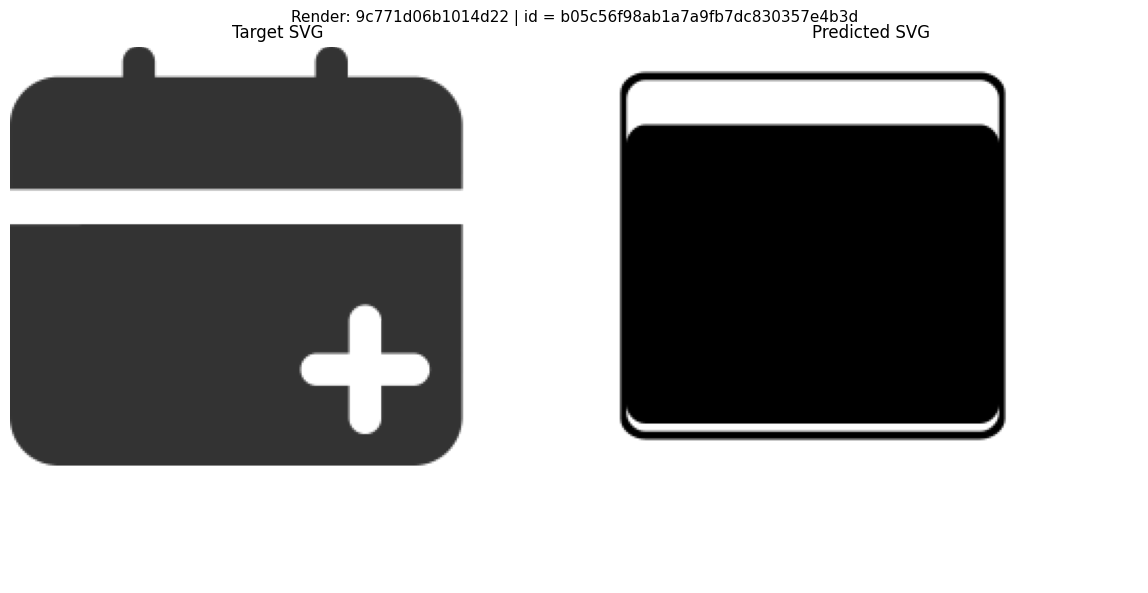

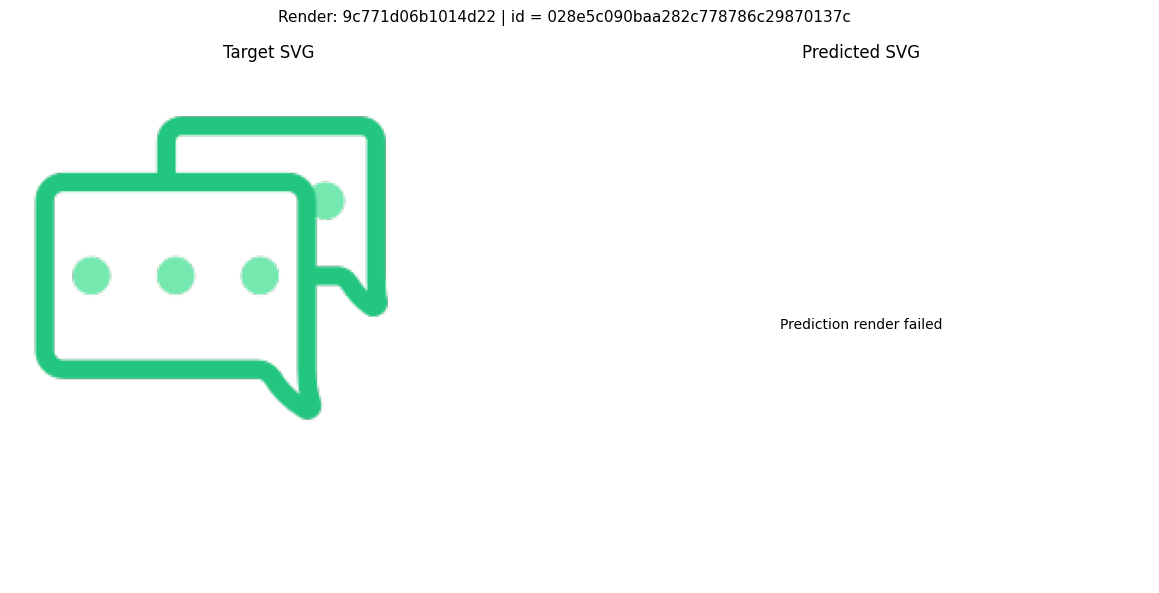

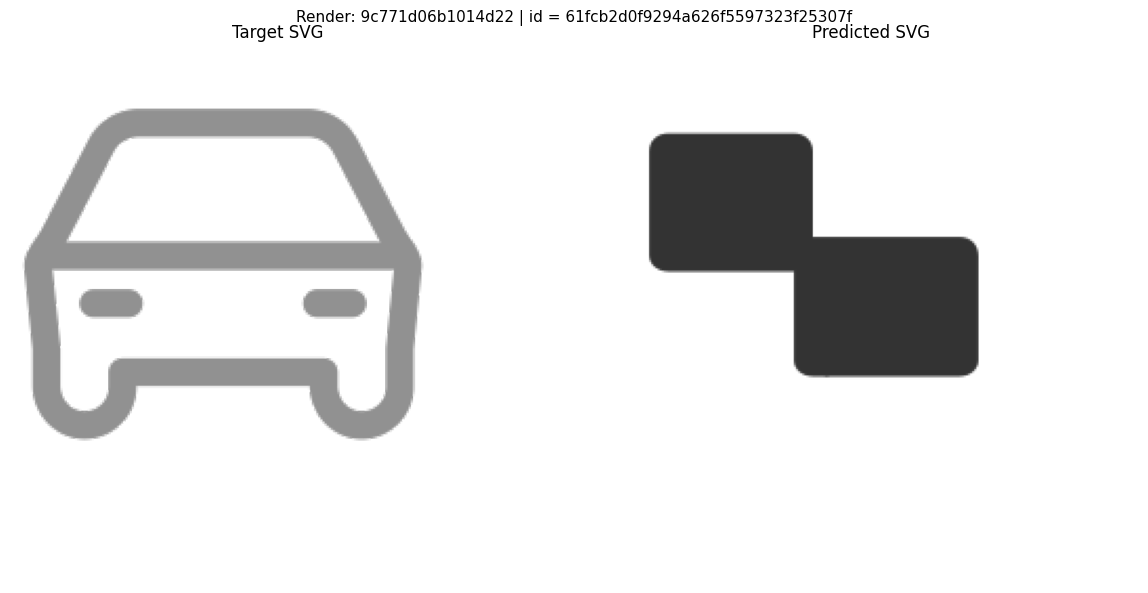

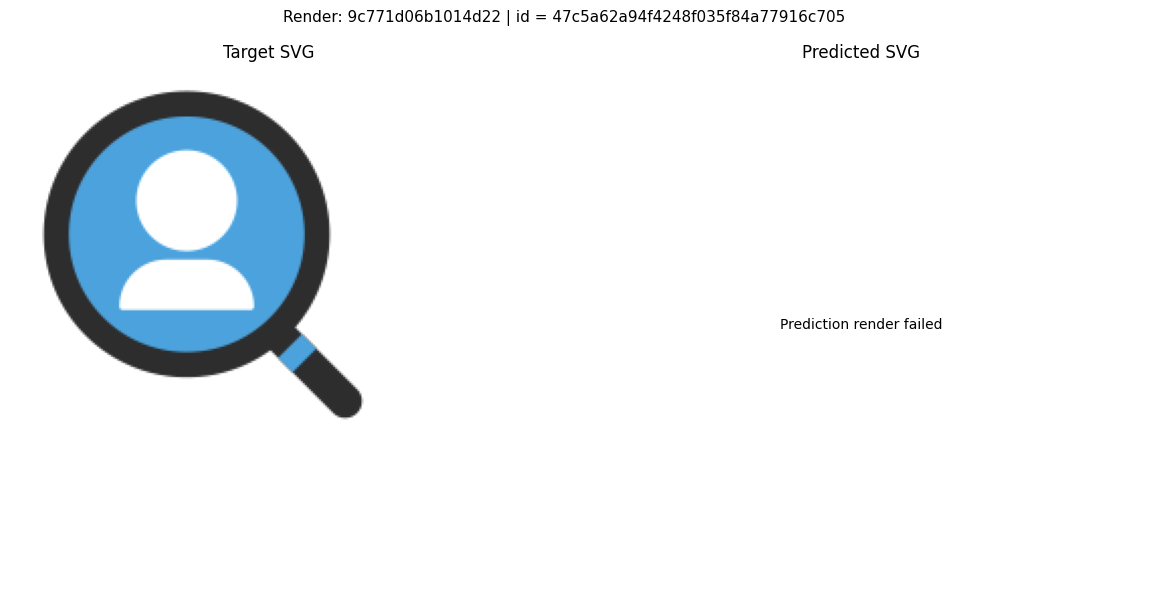

,model_id,tuning_stage,svg_open_rate,svg_close_rate,xml_parse_rate,render_rate,avg_pred_char_len,submission_valid_rate
0,c1a57bce22fe4a00,curriculum,1.0,1.0,0.8,0.8,1595.4,0.8
1,9c771d06b1014d22,best_extended,1.0,1.0,0.6,0.6,2623.0,0.6


Display cell finished.


In [14]:
import pandas as pd

from src.eval.holdout_evaluation import (
    enrich_for_display,
    merge_ranked_metadata,
    sample_percentile_buckets,
)
from src.eval.postprocess_presets import POSTPROCESS_METHODS
from src.training.lora.display import (
    display_cross_model_summary,
    display_prediction_summary,
    display_rendered_comparisons,
    display_text_comparisons,
    save_render_png_pairs,
)

# --- change these without re-running generation ---
N_TEXT_ROWS = 12
N_RENDER_ROWS = 9
PREVIEW_CHARS = 8000
SAVE_RENDER_PNGS = False
RENDER_PNG_SIZE = 512
MAX_RENDER_PNG_ROWS = None
# ---

if POSTPROCESS_METHOD not in POSTPROCESS_METHODS:
    raise ValueError(f"Unknown POSTPROCESS_METHOD. Pick one of: {sorted(POSTPROCESS_METHODS)}")

summary_rows = []
for _, rrow in reg_sub.iterrows():
    mid = str(rrow["model_id"])
    ts = str(rrow["tuning_stage"])
    eval_root = (
        WORKFLOW_ROOT / "evaluations" / "holdout_best_extended"
        if ts == "best_extended"
        else WORKFLOW_ROOT / "evaluations" / "holdout_curriculum"
    )
    out_dir = eval_root / mid
    post_path = out_dir / f"predictions_post_{POSTPROCESS_METHOD}.csv"
    if not post_path.is_file():
        raise FileNotFoundError(f"Missing {post_path}; run the generation cell first.")

    raw_df = pd.read_csv(post_path)
    disp_df = merge_ranked_metadata(raw_df, RANKED_PATH)
    enriched = enrich_for_display(disp_df, "pred_svg")
    if RUN_HOLDOUT_GENERATION_ON_BUCKET_SAMPLE_ONLY:
        sample_df = enriched.reset_index(drop=True)
    else:
        try:
            sample_df = sample_percentile_buckets(
                enriched, PERCENTILE_BUCKETS, N_SAMPLES_PER_BUCKET, SEED
            )
        except Exception:
            sample_df = enriched.sample(n=min(15, len(enriched)), random_state=SEED)

    if SAVE_RENDER_PNGS:
        paths = save_render_png_pairs(
            sample_df,
            out_dir,
            max_rows=MAX_RENDER_PNG_ROWS,
            output_width=int(RENDER_PNG_SIZE),
            output_height=int(RENDER_PNG_SIZE),
        )
        print(f"Wrote {len(paths) // 2} PNG pair(s) to {out_dir / 'render_pngs'}")

    summ = display_prediction_summary(sample_df, heading=f"model_id={mid} ({ts})")
    summary_rows.append({"model_id": mid, "tuning_stage": ts, **summ})
    display_text_comparisons(
        sample_df, title=f"Text: {mid}", n_rows=N_TEXT_ROWS, preview_chars=PREVIEW_CHARS
    )
    display_rendered_comparisons(sample_df, title=f"Render: {mid}", n_rows=N_RENDER_ROWS)

if summary_rows:
    display_cross_model_summary(summary_rows, heading="Post-training models (holdout)")
print("Display cell finished.")

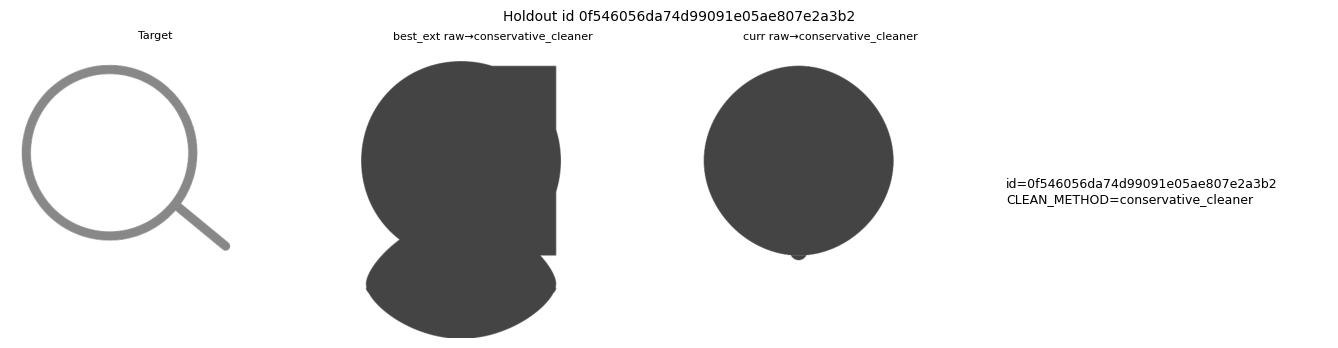

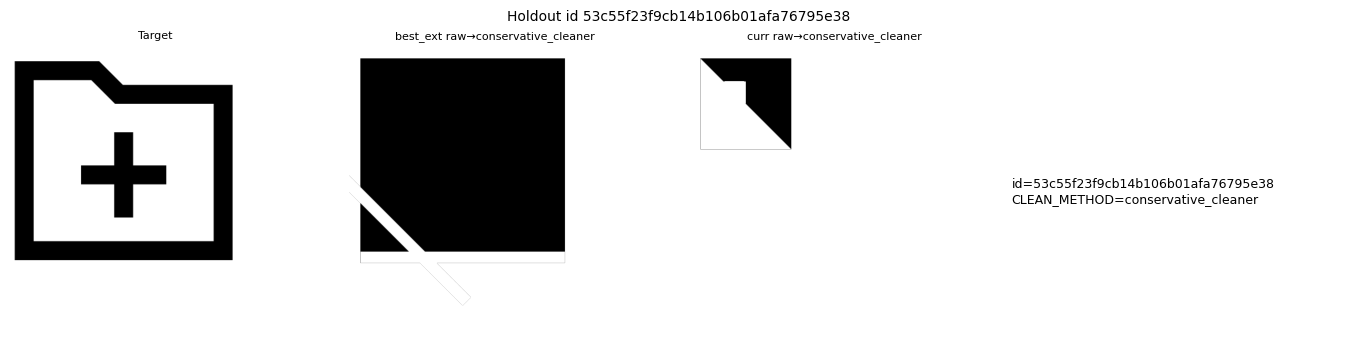

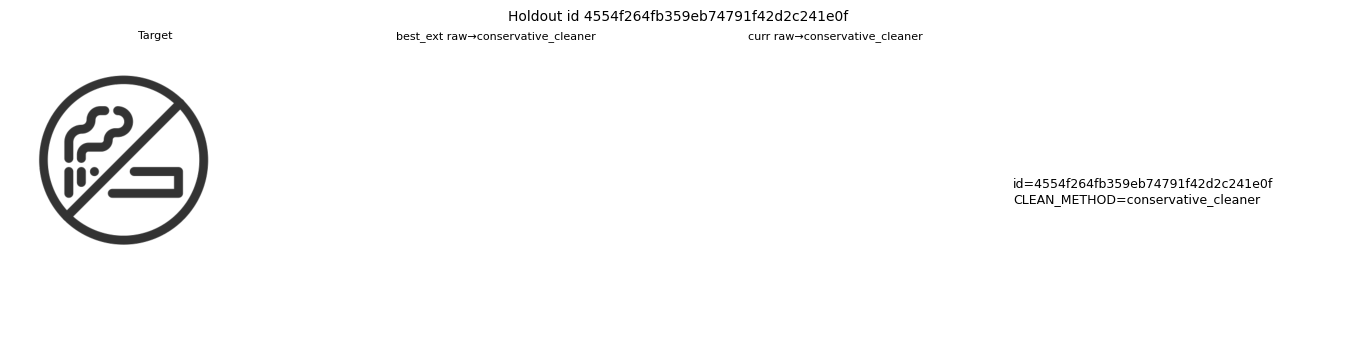

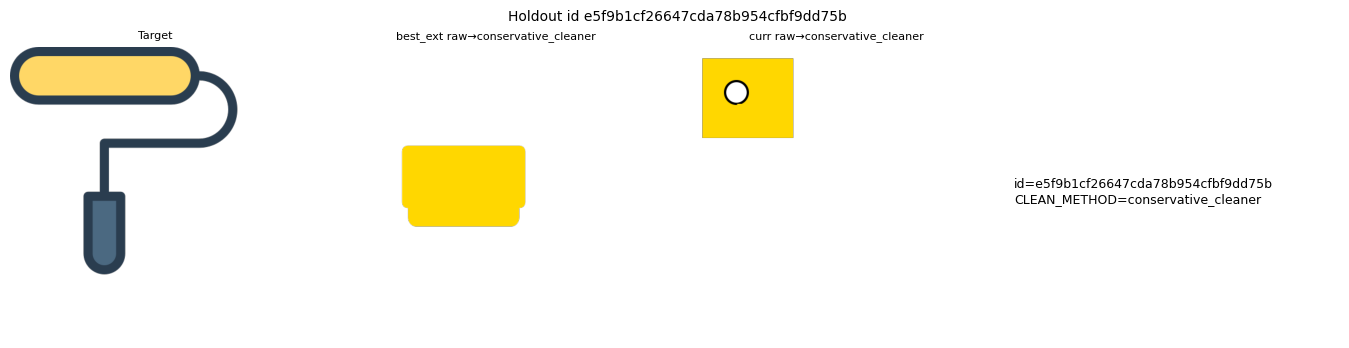

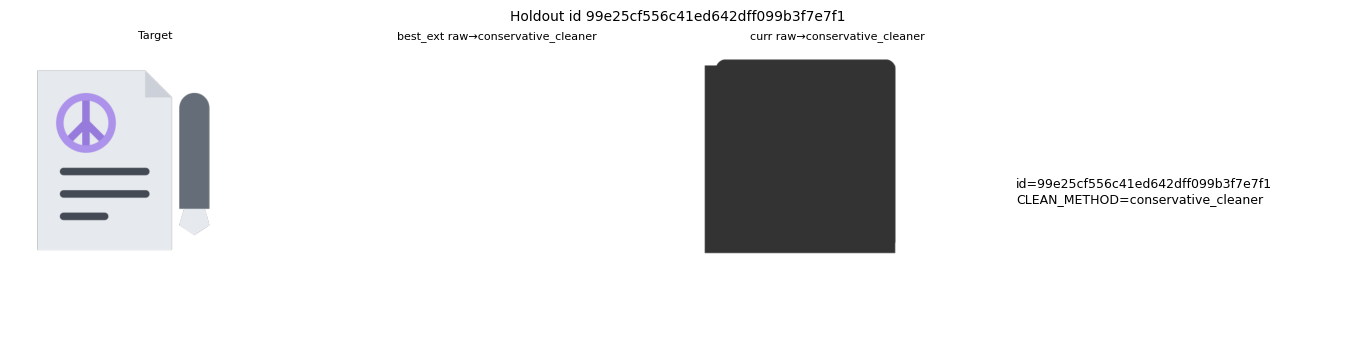

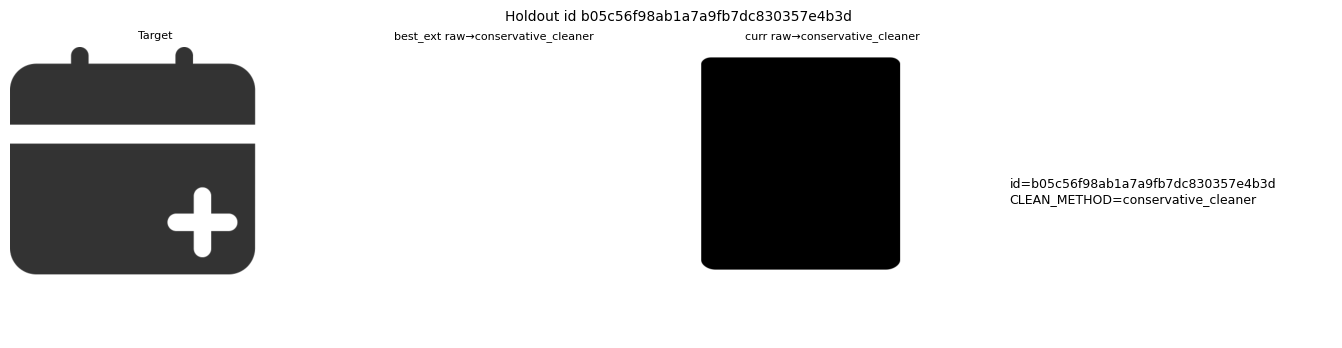

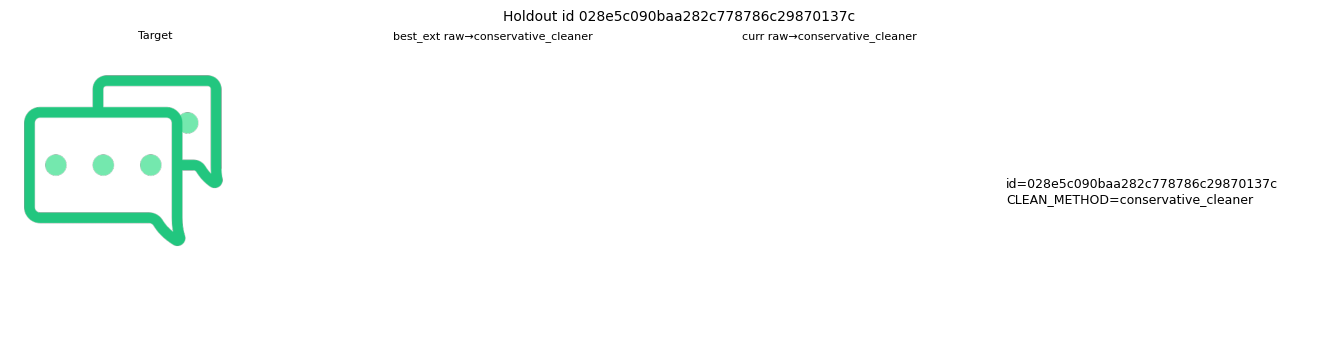

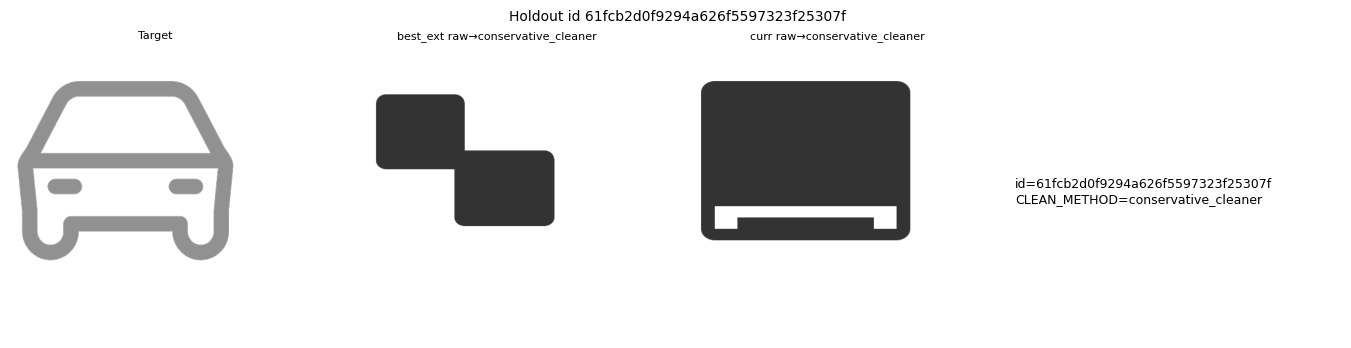

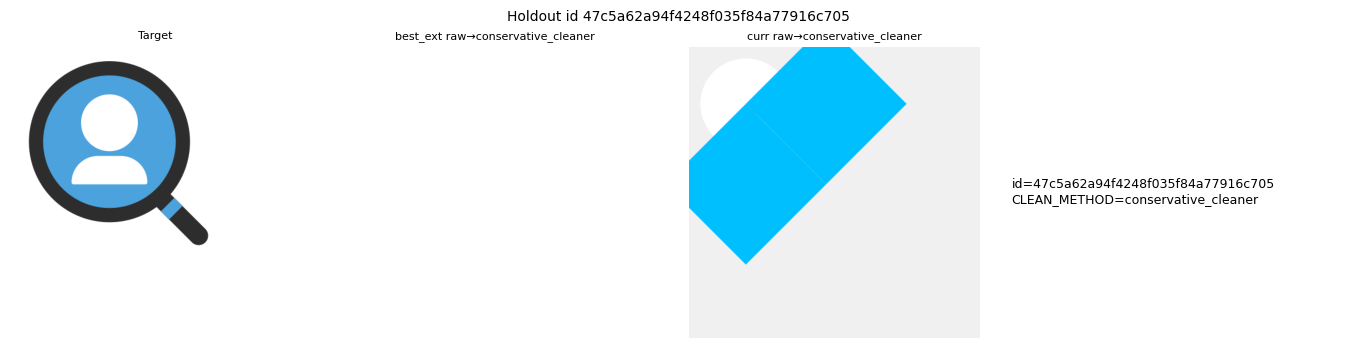

In [16]:
# --- sanity check: raw → chosen postprocess → render (two models, aligned by holdout id) ---
import matplotlib.pyplot as plt
import pandas as pd

from src.eval.postprocess_presets import POSTPROCESS_METHODS, get_postprocess_fn
from src.svg.rendering import render_svg_to_pil

# Parameters ['c1a57bce22fe4a00','78896fb7db0d4cf8']
CLEAN_METHOD = 'conservative_cleaner'  # or e.g. 'aggressive_cleaner', 'extract_only', ...
BEST_MODEL_ID = '9c771d06b1014d22' #'78896fb7db0d4cf8'
CURR_MODEL_ID = 'c1a57bce22fe4a00'
N_SHOW = 9  # how many holdout ids to plot
RENDER_SIZE = 512

if CLEAN_METHOD not in POSTPROCESS_METHODS:
    raise ValueError(f"Unknown CLEAN_METHOD; pick from {sorted(POSTPROCESS_METHODS)}")

clean_fn = get_postprocess_fn(CLEAN_METHOD)

path_be = WORKFLOW_ROOT / "evaluations" / "holdout_best_extended" / BEST_MODEL_ID / "predictions_raw.csv"
path_cu = WORKFLOW_ROOT / "evaluations" / "holdout_curriculum" / CURR_MODEL_ID / "predictions_raw.csv"

raw_be = pd.read_csv(path_be)
raw_cu = pd.read_csv(path_cu)
merged = raw_be.merge(raw_cu, on="id", suffixes=("_be", "_cu"))

for _, row in merged.head(N_SHOW).iterrows():
    rid = row["id"]
    tgt = str(row.get("target_svg_be", row.get("target_svg", "")) or "")
    rbe = str(row["raw_pred_be"] or "")
    rcu = str(row["raw_pred_cu"] or "")
    sbe = clean_fn(rbe)
    scu = clean_fn(rcu)

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    titles = ["Target", f"best_ext raw→{CLEAN_METHOD}", f"curr raw→{CLEAN_METHOD}", "(raw B / raw C text skip)"]
    imgs = [
        render_svg_to_pil(tgt, RENDER_SIZE, RENDER_SIZE),
        render_svg_to_pil(sbe, RENDER_SIZE, RENDER_SIZE),
        render_svg_to_pil(scu, RENDER_SIZE, RENDER_SIZE),
    ]
    for ax, im, t in zip(axes[:3], imgs, titles[:3]):
        ax.imshow(im)
        ax.set_title(t, fontsize=8)
        ax.axis("off")
    axes[3].axis("off")
    axes[3].text(0, 0.5, f"id={rid}\nCLEAN_METHOD={CLEAN_METHOD}", va="center", fontsize=9)
    fig.suptitle(f"Holdout id {rid}", fontsize=10)
    plt.tight_layout()
    plt.show()

In [17]:
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_path = WORKFLOW_ROOT / "evaluations" / "holdout_post_training_summary.csv"
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(summary_path, index=False)
    summary_df.to_json(summary_path.with_suffix(".json"), orient="records", indent=2)
    print(f"Wrote {summary_path} and {summary_path.with_suffix('.json')}")
    display_cross_model_summary(summary_rows, heading="Post-training models (holdout)")

Wrote /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/outputs/workflow_runs/run_1/evaluations/holdout_post_training_summary.csv and /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/outputs/workflow_runs/run_1/evaluations/holdout_post_training_summary.json


,model_id,tuning_stage,svg_open_rate,svg_close_rate,xml_parse_rate,render_rate,avg_pred_char_len,submission_valid_rate
0,c1a57bce22fe4a00,curriculum,1.0,1.0,0.8,0.8,1595.4,0.8
1,9c771d06b1014d22,best_extended,1.0,1.0,0.6,0.6,2623.0,0.6


In [18]:
# Save target/pred PNGs for each post-training model (same rows as Display `sample_df`).
from pathlib import Path

import pandas as pd

from src.eval.holdout_evaluation import (
    enrich_for_display,
    merge_ranked_metadata,
    sample_percentile_buckets,
)
from src.training.lora.display import save_render_png_pairs

RENDER_PNG_SIZE = 256
MAX_RENDER_PNG_ROWS = None  # None = all rows in sample_df; or set an int cap

for _, rrow in reg_sub.iterrows():
    mid = str(rrow["model_id"])
    ts = str(rrow["tuning_stage"])
    eval_root = (
        WORKFLOW_ROOT / "evaluations" / "holdout_best_extended"
        if ts == "best_extended"
        else WORKFLOW_ROOT / "evaluations" / "holdout_curriculum"
    )
    out_dir = eval_root / mid
    post_path = out_dir / f"predictions_post_{POSTPROCESS_METHOD}.csv"
    if not post_path.is_file():
        raise FileNotFoundError(f"Missing {post_path}; run the Generate cell first.")

    raw_df = pd.read_csv(post_path)
    disp_df = merge_ranked_metadata(raw_df, RANKED_PATH)
    enriched = enrich_for_display(disp_df, "pred_svg")
    if RUN_HOLDOUT_GENERATION_ON_BUCKET_SAMPLE_ONLY:
        sample_df = enriched.reset_index(drop=True)
    else:
        try:
            sample_df = sample_percentile_buckets(
                enriched, PERCENTILE_BUCKETS, N_SAMPLES_PER_BUCKET, SEED
            )
        except Exception:
            sample_df = enriched.sample(n=min(15, len(enriched)), random_state=SEED)

    paths = save_render_png_pairs(
        sample_df,
        out_dir,
        max_rows=MAX_RENDER_PNG_ROWS,
        output_width=int(RENDER_PNG_SIZE),
        output_height=int(RENDER_PNG_SIZE),
    )
    print(f"{mid}: wrote {len(paths) // 2} pair(s) -> {out_dir / 'render_pngs'}")

c1a57bce22fe4a00: wrote 10 pair(s) -> /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/outputs/workflow_runs/run_1/evaluations/holdout_curriculum/c1a57bce22fe4a00/render_pngs
9c771d06b1014d22: wrote 10 pair(s) -> /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/outputs/workflow_runs/run_1/evaluations/holdout_best_extended/9c771d06b1014d22/render_pngs
